# Quantum Approximate Optimization Algorithm

While quantum adiabatic computation and quantum annealing use continuous-time Hamiltonian
evolution to find ground states of optimization problems, the Quantum Approximate
Optimization Algorithm (QAOA) achieves a similar goal on gate-based quantum computers
by discretizing the Hamiltonian evolution into a sequence of alternating unitary layers.
This makes QAOA compatible with near-term quantum hardware. QAOA was introduced by Edward Farhi, Jeffrey
Goldstone, and Sam Gutmann in [A Quantum Approximate Optimization Algorithm](https://arxiv.org/abs/1411.4028) (2014).

In this tutorial, we begin by deriving QAOA through its connection with quantum annealing
and introduce the cost and mixer Hamiltonians, which are the building blocks QAOA circuits. 
We then apply QAOA to an instance of a QUBO problem, the same number
partitioning problem solved in the [QUBO Tutorial](https://sohrabganjian.github.io/blog/2026/qubo/),
and implement the optimization pipeline in PennyLane. The tutorial closes with a
discussion of the results and broader context.

<h3>Table of Contents</h3>

<ol>
  <li>Derivation of QAOA</li>
  <li>Canonical Forms of the Cost and Mixer Hamiltonians
    <ol style="list-style-type: decimal">
      <li>The Cost Hamiltonian</li>
      <li>The Mixer Hamiltonian</li>
    </ol>
  </li>
  <li>Example: Number Partitioning via QAOA
    <ol style="list-style-type: decimal">
      <li>The Number Partitioning Problem</li>
      <li>Problem Instance</li>
      <li>QAOA is a Heuristic</li>
      <li>From QUBO to Cost Hamiltonian</li>
      <li>Term Count: QUBO Entries vs Cost Hamiltonian Terms</li>
      <li>Simplification: Single-Qubit Terms Cancel</li>
      <li>Qiskit's Built-in Conversion</li>
      <li>Building the Simplified Hamiltonian Directly</li>
      <li>Rescaling</li>
      <li>QAOA Circuit</li>
    </ol>
  </li>
  <li>Conclusion</li>
</ol>

<h3>Appendix</h3>

<ol start="5">
  <li>Appendix 1: Biography</li>
  <li>Appendix 2: References and Suggested Readings</li>
</ol>

<hr>

### Derivation of QAOA

We derive QAOA through its connection to adiabatic quantum optimization, which also
underlies the idealized theory of quantum annealing explored in the
[QUBO](https://sohrabganjian.github.io/blog/2026/qubo/) tutorial. In adiabatic quantum
optimization, we define a time-dependent Hamiltonian that interpolates between two terms:

$$H(t) = A(t)\,H_M + B(t)\,H_C, \quad t \in [0, T]$$

where:
 - $H_C$ is the cost Hamiltonian encoding the optimization problem, 
 - $H_M$ is the mixer Hamiltonian, 
 - $T$ is the total evolution time, and 
 - $A(t)$, $B(t)$ are smooth functions satisfying $A(0)=1$, $B(0)=0$, $A(T)=0$, $B(T)=1$. 
 
A common pedagogical choice is the linear schedule

$$A(t) = 1 - \frac{t}{T}, \qquad B(t) = \frac{t}{T}$$

giving:

$$H(t) = \left(1 - \frac{t}{T}\right)H_M + \frac{t}{T}\,H_C$$

which we adopt here for simplicity.

The operator $H_M$ goes by several names in the literature, each reflecting a different
aspect of its role. Farhi et al. call it $H_B$ in
[*Quantum Computation by Adiabatic Evolution*](https://arxiv.org/pdf/quant-ph/0001106),
where the subscript $B$ stands for "beginning," since the system starts in its ground state.
Hen and Sarandy call it $H_d$ in
[*Driver Hamiltonians for Constrained Optimization in Quantum Annealing*](https://arxiv.org/pdf/1602.07942),
emphasizing that it drives the dynamics away from the initial state. A third name, mixer,
appears in He et al.
[*Alignment between Initial State and Mixer Improves QAOA Performance for Constrained Optimization*](https://arxiv.org/pdf/2305.03857),
reflecting the fact that its unitary mixes probability amplitudes across computational basis
states. We adopt the name $H_M$ for the remainder of this tutorial.

Roughly speaking, the adiabatic theorem states that if the Hamiltonian changes sufficiently
slowly and the instantaneous ground state remains separated from the excited spectrum by a
nonzero gap throughout the entire evolution path, then the evolving state remains close to
the instantaneous ground state at each moment. The instantaneous ground state is the ground
state of $H(t)$, not the ground state of the fixed initial or final
Hamiltonian: it is a moving target that the state tracks as $H(t)$ is slowly reshaped.
Starting from the ground state of $H_M$, the system can therefore end close to the ground
state of $H_C$, which encodes the desired solution. In the idealized adiabatic picture, the
system is initialized exactly in the ground state of $H_M$. On gate-based devices this is
prepared, for example with a layer of Hadamard gates for the standard transverse
field mixer. On annealing hardware, initialization is implemented through the device's
preparation protocol, though real devices are open systems at finite temperature and only
approximately realize this idealized picture.

The time evolution operator for the full continuous evolution is the propagator from $0$ to
$T$:

$$U = \mathcal{T}\exp\left(-i \int_0^T H(t) \, dt\right)$$

where $\mathcal{T}$ is the time-ordering operator. This notation is shorthand for the
[Dyson series](https://en.wikipedia.org/wiki/Dyson_series), which is the actual mathematical
object being defined:

$$U = I + \sum_{k=1}^{\infty} (-i)^k
      \int_0^T dt_1 \int_0^{t_1} dt_2 \cdots \int_0^{t_{k-1}} dt_k \;
      H(t_1)\, H(t_2) \cdots H(t_k)$$

Each term is a nested integral of matrix products, with integration limits that enforce time
ordering: $t_1 \geq t_2 \geq \cdots \geq t_k$. The symbol $\mathcal{T}$ packages this
entire infinite series into a compact expression. For a careful discussion of what this
notation does and does not mean, see this
[PennyLane blog post](https://pennylane.ai/blog/2024/09/time_ordered_exponential/).

The time-ordering operator arises because $H_M$ and $H_C$ generally do not commute, meaning
$H_M H_C \neq H_C H_M$ as matrix products. As a result, $H(t_1)$ and $H(t_2)$ at two
different times are themselves different matrices that also fail to commute, and the order
in which the system experiences them matters physically. $\mathcal{T}$ instructs us to sort
each term in the power series so that operators at earlier times always act before operators
at later times. If $H(t)$ were the same operator at every moment, time ordering would be
irrelevant and this expression would reduce to $e^{-iHT}$.

We can approximate $U$ by dividing $[0, T]$ into $p$ discrete steps of size
$\delta t = \frac{T}{p}$ and applying the Trotter-Suzuki decomposition at each step. Within each
small interval $H(t)$ barely changes, so we treat it as approximately constant. Over one
step at time $t_k$, the Hamiltonian is $H(t_k) = A(t_k) H_M + B(t_k) H_C$, and the
evolution splits as:

$$e^{-i\left(A(t_k) H_M + B(t_k) H_C\right)\delta t}
  \approx e^{-i B(t_k) H_C\,\delta t}\,e^{-i A(t_k) H_M\,\delta t}
  + \mathcal{O}(\delta t^2)$$

The error in this approximation is controlled by how much $H_C$ and $H_M$ fail to commute.
Concretely, $[H_C, H_M] = H_C H_M - H_M H_C$ is a matrix that is zero if and only if the
two operators commute. Informally, the total accumulated error over all $p$ steps scales as:

$$\mathcal{O}\left(\|[H_C, H_M]\|\,\frac{T^2}{p}\right)$$

where $\|[H_C, H_M]\|$ is the operator norm of the commutator, measuring the largest factor
by which it can stretch any unit quantum state. This is an informal first-order scaling
rather than a standalone exact bound: the precise constant depends on operator norms, the
smoothness of the schedule, and the error metric used. Applying this decomposition at every
step and identifying $\gamma_k = B(t_k)\,\delta t$ and $\beta_k = A(t_k)\,\delta t$ yields:

$$U \approx \prod_{k=1}^{p} e^{-i\gamma_k H_C}\,e^{-i\beta_k H_M}$$

For the linear schedule this gives $\gamma_k = \left(\frac{k}{p}\right)\,\delta t$ and
$\beta_k = \left(1-\frac{k}{p}\right)\,\delta t$, but other schedules produce different angle sequences. As
$p \to \infty$ the discrete product converges to the time-ordered evolution.

In QAOA, instead of fixing the angles from a schedule, we replace them with real
numbers $\gamma_k$ and $\beta_k$ to be chosen by a classical optimizer:

$$|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle =
  \underbrace{e^{-i\beta_p H_M}\,e^{-i\gamma_p H_C}}_{\text{layer } p}
  \cdots
  \underbrace{e^{-i\beta_1 H_M}\,e^{-i\gamma_1 H_C}}_{\text{layer } 1}
  |\psi_0\rangle$$

Here $|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle$ denotes the quantum state produced
by running the circuit with a particular choice of the $2p$ angles
$(\gamma_1, \dots, \gamma_p, \beta_1, \dots, \beta_p)$. It is the output state of the
circuit, labeled by the parameters that define it.

Within each layer the ordering of the two unitaries matters: since $H_M$ and $H_C$ do not
commute, swapping their order produces a different unitary and a different output state. The
convention adopted here, and in the original Farhi et al. formulation, is to apply the cost
unitary $e^{-i\gamma_k H_C}$ first, followed by the mixer unitary $e^{-i\beta_k H_M}$.
Both orderings are valid first-order Trotter approximations to the continuous evolution with
the same $\mathcal{O}(\delta t^2)$ error. What matters is that the ordering is fixed and
consistent across all $p$ layers: the parameters $\gamma_k$ and $\beta_k$ are optimized for
a given circuit structure, and changing the ordering would alter the landscape and
invalidate the parameters found.

$|\psi_0\rangle$ is the ground state of $H_M$, prepared before the circuit begins. This
choice mirrors the adiabatic requirement that the system starts in the ground state of the
initial Hamiltonian. The specific form of $|\psi_0\rangle$ depends on the choice of $H_M$;
for other mixers it may differ from what we derive below.

The standard choice is $H_M = -\sum_{i=1}^N \sigma_x^{(i)}$, where $\sigma_x$ is the
Pauli-X matrix:

$$\sigma_x = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$

and $\sigma_x^{(i)}$ denotes the operator that acts as $\sigma_x$ on qubit $i$ and as the
identity on all other qubits:

$$\sigma_x^{(i)} = I \otimes \cdots \otimes \underbrace{\sigma_x}_{i} \otimes \cdots \otimes I.$$

Each such term is a $2^N \times 2^N$ matrix. The sum notation $\sum_i \sigma_x^{(i)}$
abbreviates a sum of $N$ such matrices, each carrying this tensor product structure.

The computational basis states $|0\rangle$ and $|1\rangle$ are the eigenstates of
$\sigma_z$. The eigenstates of $\sigma_x$ are instead the equal-weight superpositions:

$$|+\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}1\\1\end{pmatrix}, \qquad
  |-\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}1\\-1\end{pmatrix}$$

with eigenvalues $+1$ and $-1$ respectively. The minus sign in $H_M$ flips these
eigenvalues, so $-\sigma_x^{(i)}$ has eigenvalue $-1$ for $|+\rangle$ and $+1$ for
$|-\rangle$ on qubit $i$. Since the $N$ terms act on different qubits they commute, and the ground state of the full sum is the tensor product of the single-qubit ground states. Putting every qubit in $|+\rangle$ gives total energy $-N$, so:

$$|\psi_0\rangle = |+\rangle^{\otimes N}$$

This state assigns equal amplitude to all $2^N$ computational basis states, reflecting the
fact that no solution is preferred over any other before the optimization begins.

The parameters $\boldsymbol{\gamma} = (\gamma_1, \dots, \gamma_p)$ and
$\boldsymbol{\beta} = (\beta_1, \dots, \beta_p)$ are then optimized to minimize:

$$\langle \boldsymbol{\gamma}, \boldsymbol{\beta} | H_C | \boldsymbol{\gamma},
\boldsymbol{\beta} \rangle$$

This annealing picture shows that, under the same conditions that make the underlying
adiabatic evolution effective, sufficiently fine QAOA discretizations can approximate that
continuous evolution. At the same time, QAOA is more flexible: its angles are optimized
variationally and need not follow any smooth annealing schedule. Annealing-derived angles
provide one principled initialization or interpretation of QAOA, but the optimized
parameters may exploit non-adiabatic behavior and find good solutions at much smaller $p$
than the annealing perspective alone would suggest.

---

## Canonical Forms of the Cost and Mixer Hamiltonians

### The Cost Hamiltonian

For QAOA to work as described, $H_C$ is typically diagonal in the computational basis. This
means each computational basis state $|z\rangle$ is an eigenstate:

$$H_C |z\rangle = C(z)|z\rangle$$

where $C(z)$ is the classical cost associated with bitstring $z \in \{0,1\}^N$. A practical consequence is that measuring the circuit output returns a bitstring whose cost $C(z)$ can then be evaluated classically. 

Since every operator diagonal in the computational basis can be decomposed into sums
and products of $I$ and $Z$ operators, the canonical form is:

$$H_C = \sum_\alpha c_\alpha \, P_\alpha, \qquad P_\alpha \in \{I, \sigma_z^{(i)},
\sigma_z^{(i)}\sigma_z^{(j)}, \sigma_z^{(i)}\sigma_z^{(j)}\sigma_z^{(k)}, \ldots\}$$

where $c_\alpha$ are real coefficients. Because all terms $P_\alpha$ are diagonal in
the same basis, they commute, and the cost unitary factorizes:

$$e^{-i\gamma H_C} = e^{- i \gamma \sum\limits_{\alpha} c_{\alpha} P_{\alpha}} = \prod_\alpha e^{-i\gamma c_\alpha P_\alpha}$$

**From canonical form to gates.** The MaxCut problem is an example of this pairwise $ZZ$ form, and the one on
which Farhi et al. (2014) originally demonstrated QAOA. In MaxCut, the goal is to
partition the vertices of a graph $G = (V, E)$ into two sets so as to maximize the
number of edges between them. Encoding each vertex $i$ as a qubit, an edge $(j,k)$ is
cut when the two endpoints are in different partitions. Since opposite partitions
correspond to opposite $\sigma_z$ eigenvalues, the product $\sigma_z^{(j)}\sigma_z^{(k)}$
has eigenvalue $-1$ for a cut edge and $+1$ for an uncut one. The per-edge term:

$$C_{\langle jk \rangle} = \frac{1}{2}\!\left(1 - \sigma_z^{(j)}\sigma_z^{(k)}\right)$$

therefore equals $1$ for cut edges and $0$ for uncut edges. It is the indicator function
of the cut, directly transcribed into the $\sigma_z$ eigenbasis. Summing over all edges
gives (eqs. (11)-(12) in Farhi et al.):

$$H_C^{\text{MaxCut}} = \sum_{\langle j,k\rangle \in E} \frac{1}{2}\!\left(1 - \sigma_z^{(j)}\sigma_z^{(k)}\right)$$

Farhi et al. maximize $\langle H_C^{\text{MaxCut}} \rangle$, since larger values correspond
to more cut edges. This tutorial follows the convention of minimizing $\langle H_C \rangle$,
which for MaxCut would require negating: $H_C \to -H_C^{\text{MaxCut}}$. The gate structure is unaffected by this sign flip. The cost unitary still decomposes into one IsingZZ gate per edge, with $\phi = \mp\gamma$ depending on the convention.



### The Mixer Hamiltonian

The role of $H_M$ is to move probability amplitude between candidate solutions,
allowing the circuit to explore the solution space. For this to work, the mixer unitary
$e^{-i\beta H_M}$ should satisfy a few conditions. As noted in
[Hadfield et al. (2019)](https://arxiv.org/abs/1709.03489) in Section 3, it must be
able to connect any two feasible states through repeated application, and for
constrained problems it should preserve the feasible subspace. A further practical
requirement is that the ground state of $H_M$ be efficiently preparable. An informal
consequence of these conditions is that $H_M$ and $H_C$ should not commute: if they
did, $e^{-i\beta H_M}$ would leave the eigenspaces of $H_C$ invariant, and the
alternating circuit structure would produce no useful variation in the energy landscape.
There is no single best mixer Hamiltonian, and the appropriate
choice of $H_M$ is problem-dependent.

### The $\sigma_x$ mixer

For unconstrained problems, where every bitstring is a valid candidate solution, the
standard choice is:

$$H_M = -\sum_{i=1}^N \sigma_x^{(i)}$$

where $N$ is the number of qubits. Assuming the hardware initializes qubits in $|0\rangle^{\otimes N}$, one Hadamard gate per
qubit is applied before the circuit begins to prepare the required ground state:

$$H|0\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}1\\1\end{pmatrix} = |+\rangle$$

This initialization is specific to this choice of $H_M$. A different mixer Hamiltonian
would have a different ground state and would require different preparation gates.

Exponentiating $H_M$ gives the mixer unitary applied at each of the $p$ layers:

$$e^{-i\beta H_M} = \prod_{i=1}^N e^{i\beta\,\sigma_x^{(i)}}
= \bigotimes_{i=1}^N R_x(-2\beta)_i$$

where $R_x(\theta) = \exp\!\bigl(-i\tfrac{\theta}{2}\sigma_x\bigr)$ is a single-qubit
rotation about the $x$-axis, and the product runs over all $N$ qubits within that
layer. 

$H_M$ is fixed throughout the circuit and determines the axis of rotation. What varies
between layers is the angle $\beta_k$, one for each layer $k = 1, \ldots, p$. Using
$\sigma_x^2 = I$, the matrix exponential has the closed form:

$$e^{i\beta\sigma_x} = \cos\beta\, I + i\sin\beta\, \sigma_x
= \begin{pmatrix}\cos\beta & i\sin\beta \\ i\sin\beta & \cos\beta\end{pmatrix}$$

Different values of $\beta$ give different matrices: $\beta = 0$ recovers the identity
(no rotation), while $\beta = \pi/2$ corresponds to a full $\pi$ rotation about the
$x$-axis up to a global phase. The $p$ angles
$(\beta_1, \ldots, \beta_p)$ are variational parameters tuned by the classical
optimizer.

On the choice of rotation axis: $\sigma_z$ is ruled out because
$-\sum_i \sigma_z^{(i)}$ is diagonal in the computational basis and commutes with
$H_C$, so its unitary would only add phases to bitstrings without moving amplitude
between them. Between $\sigma_x$ and $\sigma_y$, the choice is largely conventional.
Both provide the required non-commutativity and connectivity. The ground state of
$-\sum_i \sigma_y^{(i)}$ is $\bigl(\tfrac{|0\rangle + i|1\rangle}{\sqrt{2}}\bigr)^{\otimes N}$,
which requires different initialization gates; apart from that, the circuit structure
is identical. Farhi et al. (2014) used $\sigma_x$, and the real-valued ground state
$|+\rangle$ prepared by the standard Hadamard gate makes it the natural default.

Depending on the structure of the problem, a different choice of $H_M$ may be more
appropriate.

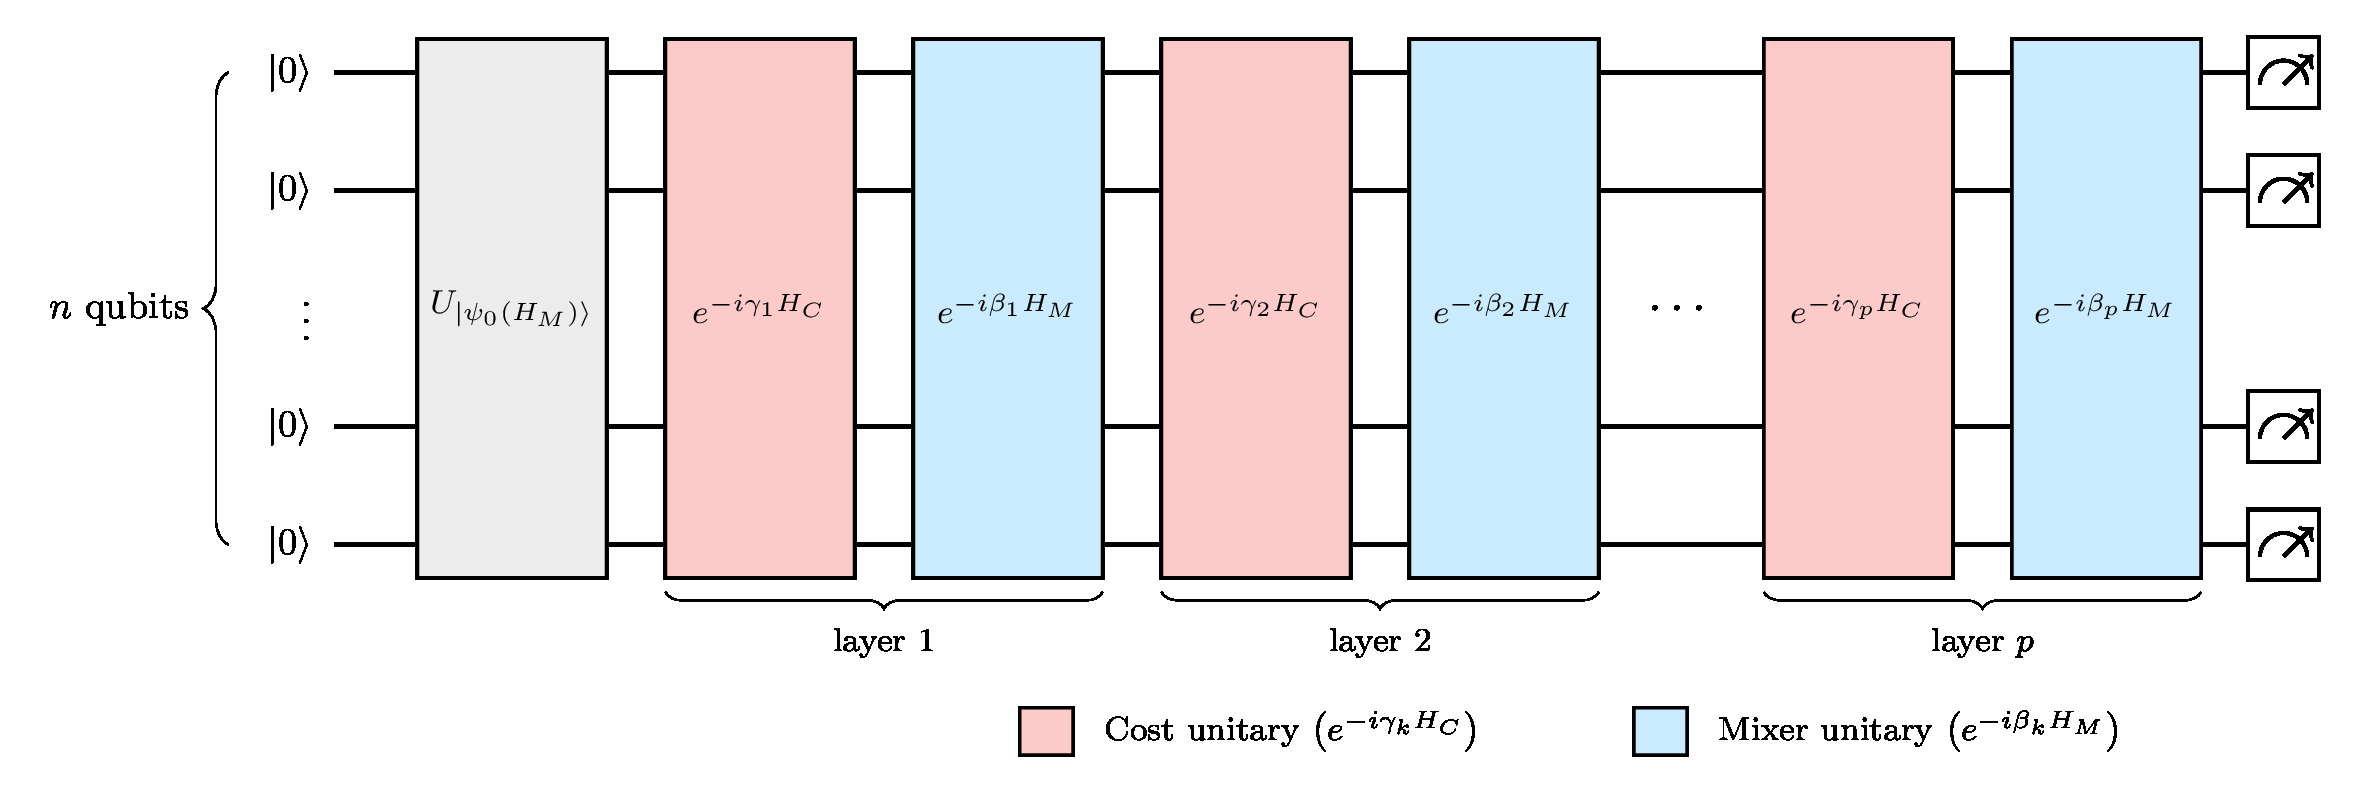

<p style="text-align: center; font-style: italic; font-size: 0.88em;
          color: #555; margin-top: 2px; max-width: 820px;
          margin-left: auto; margin-right: auto;">
  <strong>Figure 1.</strong>
  QAOA circuit for $n$ qubits and $p$ layers. Each qubit is initialized to $|0\rangle$
  and acted on by $U_{|\psi_0(H_M)\rangle}$, which prepares the ground state of the
  chosen mixer Hamiltonian $H_M$. The circuit then alternates between the cost unitary
  $e^{-i\gamma_k H_C}$ (red) and the mixer unitary $e^{-i\beta_k H_M}$ (blue) for
  $k = 1, \ldots, p$. The variational parameters
  $(\gamma_1, \ldots, \gamma_p,\,\beta_1, \ldots, \beta_p)$ are optimized classically
  to minimize $\langle H_C \rangle$. Each qubit is measured in the computational basis
  at the end of the circuit.
</p>

---
### Example: Number Partitioning via QAOA

Having introduced the QAOA algorithm, we now apply it to a concrete combinatorial optimization problem. We revisit the number partitioning problem, which was previously solved using a classical exact solver and a simulated annealing sampler in the [QUBO tutorial](https://sohrabganjian.github.io/blog/2026/qubo/), where the connection to quantum annealing and Ising models was also discussed. Here we tackle the same instance using a gate-based quantum approach.

### The Number Partitioning Problem

Given a multiset of positive integers $S = \{s_1, s_2, \ldots, s_n\}$, the goal is
to partition the index set into two disjoint subsets $P_1$ and $P_2$ such that the
absolute difference between the sums of each subset is minimized:

$$\min_{P_1} \left| \sum_{i \in P_1} s_i \;-\; \sum_{i \notin P_1} s_i \right|$$

If the total sum is even and a perfect split exists, the minimum is zero, and both subsets
sum to $\frac{\text{total}}{2}$. For a detailed treatment of the QUBO formulation see the [QUBO tutorial](https://sohrabganjian.github.io/blog/2026/qubo/).

### Problem Instance

We work with the multiset:

$$C = \{2,\, 10,\, 3,\, 8,\, 5,\, 7,\, 9,\, 5,\, 3,\, 2\}, \qquad \sum_i c_i = 54$$

The target for a perfect partition is for each subset to sum to $54/2 = 27$.
One such optimal solution is:

$$P_1 = \{2,\, 8,\, 9,\, 5,\, 3\} \quad (\text{sum} = 27), \qquad
  P_2 = \{10,\, 3,\, 5,\, 7,\, 2\} \quad (\text{sum} = 27)$$
  
Encoding each element as a qubit, $x_i = 0$ for $P_1$, $x_i = 1$ for $P_2$, this
partition corresponds to the bitstring $|0110110001\rangle$. In total, this instance has
23 distinct optimal partitions, 46 when counting both orientations of each split, out of
$2^{10} = 1024$ possible bitstrings.

### QAOA is a Heuristic

Unlike the exact solver used in the previous tutorial, QAOA is a variational heuristic.
It does not guarantee finding the exact ground state at finite circuit depth $p$. Instead,
it concentrates probability amplitude on near-optimal solutions while suppressing poor
ones. The approximation improves with $p$ and converges to the exact answer only as
$p \to \infty$.

A useful observation is that for this instance, not all values of the partition imbalance
are reachable. Define the imbalance as:

$$|\text{diff}| = \left|\,\sum\limits_{i \in P_1} c_i - \sum\limits_{i \in P_2} c_i\,\right|$$

Since $\sum\limits_{i \in P_1} c_i + \sum\limits_{i \in P_2} c_i = 54$, substituting $\sum\limits_{i \in P_2} c_i = 54 - \sum\limits_{i \in P_1} c_i$ gives:

$$|\text{diff}| = \left|\, 2\,\sum\limits_{i \in P_1} c_i - 54 \,\right|$$

The term $2\,\sum\limits_{i \in P_1} c_i$ is always even, divisible by 2, and subtracting 54, which
is also even, keeps the result even. Therefore $|\text{diff}|$ is always even; values
such as 1, 3, 5, $\ldots$ are structurally impossible for this instance.

The achievable solution tiers are:

| $|\text{diff}|$ | $\sum\limits_{i \in P_1} c_i$ | $\sum\limits_{i \in P_2} c_i$ | Description |
|:---:|:---:|:---:|:---|
| 0 | 27 | 27 | Perfect partition |
| 2 | 28 | 26 | One unit off balance |
| 4 | 29 | 25 | Two units off balance |
| 6 | 30 | 24 | Three units off balance |
| $\vdots$ | $\vdots$ | $\vdots$ | $\vdots$ |

Rather than demanding a perfect $|\text{diff}| = 0$ outcome, we will evaluate QAOA's
performance across all solution tiers, measuring how much probability mass it concentrates
near the optimum relative to a uniform random baseline.

Note for the QUBO formulation, we do not optimize the absolute imbalance directly. Instead, we minimize its square:
$$
\left(\sum_{i \in P_1} c_i - \sum_{i \in P_2} c_i\right)^2.
$$
This produces a polynomial objective suitable for QUBO methods, and it has the same
minimizers as the absolute difference.
Thus the optimal partitions are unchanged, even though the numerical objective differs.


To implement and simulate QAOA, we use PennyLane. The implementation follows three steps: constructing the cost Hamiltonian $H_C$ from the QUBO matrix $Q$, defining the mixer Hamiltonian $H_M$, and building the variational circuit. We begin with the QUBO matrix, which is identical to the one derived in the [QUBO tutorial](https://sohrabganjian.github.io/blog/2026/qubo/).

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# Problem data
C     = [2, 10, 3, 8, 5, 7, 9, 5, 3, 2]
n     = len(C)
total = sum(C)   # 54  ->  perfect partition: each side sums to 27

# QUBO matrix
Q = np.zeros((n, n))
for i in range(n):
    Q[i, i] = 4 * C[i] * (C[i] - total)
    for j in range(i + 1, n):
        Q[i, j] = 8 * C[i] * C[j]

### From QUBO to Cost Hamiltonian

The QUBO objective encodes the optimization problem in terms of binary variables
$x_i \in \{0, 1\}$:

$$f(\mathbf{x}) = \sum_i Q_{ii}\, x_i + \sum_{i<j} Q_{ij}\, x_i x_j$$

To construct a quantum Hamiltonian from this expression, we replace each classical binary
variable $x_i$ with a quantum operator whose eigenvalues are exactly $0$ and $1$.
The Pauli-Z operator $\sigma_z$ has eigenvalues $+1$ and $-1$:

$$\sigma_z |0\rangle = +1\,|0\rangle, \qquad \sigma_z |1\rangle = -1\,|1\rangle$$

The operator $\hat{n}_i = \frac{I - \sigma_z^{(i)}}{2}$, written explicitly as a matrix,
is:

$$\hat{n} = \frac{1}{2}\begin{pmatrix}1 & 0 \\ 0 & 1\end{pmatrix}
- \frac{1}{2}\begin{pmatrix}1 & 0 \\ 0 & -1\end{pmatrix}
= \begin{pmatrix}0 & 0 \\ 0 & 1\end{pmatrix}$$

with eigenvalues $0$ and $1$:

$$\hat{n}\,|0\rangle = 0\cdot|0\rangle, \qquad \hat{n}\,|1\rangle = 1\cdot|1\rangle$$

We replace each $x_i$ with $\hat{n}_i$, promoting the classical cost function to a
quantum operator. When the resulting Hamiltonian acts on any computational basis state
$|z\rangle = |z_1 z_2 \cdots z_n\rangle$, each $\hat{n}_i$ returns the eigenvalue $z_i$,
so:

$$H_C\,|z\rangle = f(z_1, z_2, \ldots, z_n)\,|z\rangle$$

where $H_C$ here includes the full promoted expression before dropping any constants.
The ground-state subspace of $H_C$ is spanned by all computational basis states
$|z^\star\rangle$ corresponding to optimal bitstrings, since for this problem there are
multiple degenerate optimal solutions.

Substituting $x_i \to \hat{n}_i$ into the linear terms:

$$Q_{ii}\, x_i \;=\; \frac{Q_{ii}}{2}\,I \;-\; \frac{Q_{ii}}{2}\,Z_i$$

and into the quadratic terms, using
$(I - Z_i)(I - Z_j) = I - Z_i - Z_j + Z_iZ_j$:

$$Q_{ij}\, x_i x_j \;=\; \frac{Q_{ij}}{4}\,I \;-\; \frac{Q_{ij}}{4}\,Z_i
\;-\; \frac{Q_{ij}}{4}\,Z_j \;+\; \frac{Q_{ij}}{4}\,Z_iZ_j$$

Summing all terms, the objective separates into a constant and an operator part:

$$\tilde{H}_C \;=\; \underbrace{\sum_i \frac{Q_{ii}}{2} + \sum_{i<j}\frac{Q_{ij}}{4}}_{\text{constant}}
\;-\; \frac{1}{2}\sum_i Q_{ii}\,Z_i
\;-\; \frac{1}{4}\sum_{i<j} Q_{ij}\,(Z_i + Z_j)
\;+\; \frac{1}{4}\sum_{i<j} Q_{ij}\,Z_iZ_j$$

The constant shifts every eigenvalue by the same amount and does not change which
bitstring achieves the minimum. We drop the constant and denote the remaining operator by $H_C$. Then $H_C|z\rangle = f(z)|z\rangle$ up to an additive constant. Since all remaining terms are products of $Z$ operators, $H_C$ is diagonal in the
computational basis. Each term maps directly to a PennyLane operator: single-qubit
$Z_i$ terms become `qml.PauliZ(i)` and two-qubit $Z_iZ_j$ terms become
`qml.PauliZ(i) @ qml.PauliZ(j)`.


One practical consideration is rescaling. If the coefficients in $Q$ are large, then the phases generated by $e^{-i\gamma H_C}$ can vary rapidly as a function of $\gamma$, making the optimization landscape more sensitive to the choice of parameters. Replacing $H_C$ by $H_C/s$ for some positive scalar $s$ does not change the underlying problem: it simply rescales the parameterization of $\gamma$, since

$$ e^{-i \gamma \left( \frac{H_C}{s} \right)} = e^{-i \left( \frac{\gamma}{s} \right) H_C}.$$

Thus the ground-state subspace and the set of optimal bitstrings are unchanged. In practice, choosing a moderate scale can make the relevant $\gamma$ values easier to search over numerically.

Given the explanaiton above we implement the cost Hamiltonian. 

In [2]:
# QUBO -> cost Hamiltonian
#   x_i = (I - Z_i)/2
#   Q_ii x_i        ->  -Q_ii/2 · Z_i
#   Q_ij x_i x_j    ->  -Q_ij/4 · Z_i  -Q_ij/4 · Z_j  +Q_ij/4 · Z_iZ_j
coeffs, ops = [], []

for i in range(n):
    coeffs.append(-Q[i, i] / 2)
    ops.append(qml.PauliZ(i))

for i in range(n):
    for j in range(i + 1, n):
        coeffs.append(-Q[i, j] / 4)
        ops.append(qml.PauliZ(i))
        coeffs.append(-Q[i, j] / 4)
        ops.append(qml.PauliZ(j))
        coeffs.append( Q[i, j] / 4)
        ops.append(qml.PauliZ(i) @ qml.PauliZ(j))

scale   = max(abs(c) for c in coeffs)
cost_h  = qml.Hamiltonian([c / scale for c in coeffs], ops)

print(f"Normalization scale : {scale:.1f}")
print(f"Coefficient range   : [{min(c/scale for c in coeffs):.3f},  "
      f"{max(c/scale for c in coeffs):.3f}]")

print(f"Cost Hamiltonian : {len(cost_h.coeffs)} terms")

Normalization scale : 880.0
Coefficient range   : [-0.205,  1.000]
Cost Hamiltonian : 145 terms


### Term Count: QUBO Entries vs Cost Hamiltonian Terms

The implementation above produces 145 terms, which is more than the number of entries
in the QUBO matrix. To understand why, note that $Q$ is a $10 \times 10 = 100$-entry
matrix, but the objective function only uses the upper triangular portion:

- 10 diagonal entries $Q_{ii}$ representing the linear terms
- $\binom{10}{2} = 45$ upper-triangular entries $Q_{ij}$ with $i < j$ representing the quadratic terms

This gives 55 active entries. For reference, a quantum annealer programs
directly with this Ising representation: up to $n$ qubit fields and up to
$\binom{n}{2}$ coupler strengths, for a total of at most $n + \binom{n}{2}$
parameters.

The gate-based QAOA cost Hamiltonian starts with more terms because each quadratic entry
$Q_{ij} x_i x_j$ expands into three operator terms after the substitution
$x_i \to \frac{I - Z_i}{2}$: one $Z_i$, one $Z_j$, and one $Z_iZ_j$. The 10 diagonal entries
each contribute one $Z_i$ term, and the 45 off-diagonal entries each contribute three,
giving $10 + 45 \times 3 = 145$ terms before any simplification.

In [3]:
n_linear    = n
n_quadratic = n * (n - 1) // 2

print(f"QUBO matrix size         : {n} x {n} = {n**2} entries")
print(f"Active upper-triangular  : {n_linear} diagonal + {n_quadratic} off-diagonal = "
      f"{n_linear + n_quadratic} entries")
print()
print(f"H_C terms from diagonal  : {n_linear}  (one Z_i per diagonal entry)")
print(f"H_C terms from quadratic : {n_quadratic} x 3 = {3*n_quadratic}  "
      f"(Z_i + Z_j + Z_iZ_j per off-diagonal entry)")
print(f"H_C total (unsimplified) : {n_linear + 3*n_quadratic}")
print()
print(f"Confirmed: len(cost_h.coeffs) = {len(cost_h.coeffs)}")

QUBO matrix size         : 10 x 10 = 100 entries
Active upper-triangular  : 10 diagonal + 45 off-diagonal = 55 entries

H_C terms from diagonal  : 10  (one Z_i per diagonal entry)
H_C terms from quadratic : 45 x 3 = 135  (Z_i + Z_j + Z_iZ_j per off-diagonal entry)
H_C total (unsimplified) : 145

Confirmed: len(cost_h.coeffs) = 145


### Simplification: Single-Qubit Terms Cancel

Of the 145 terms, 100 are single-qubit $Z_i$ operators. When grouped by qubit index and
their coefficients summed, each group cancels to zero for this problem instance, leaving
only the 45 two-qubit $Z_iZ_j$ terms.

To see why, recall that the QUBO matrix entries for number partitioning are
$Q_{ii} = 4c_i(c_i - A)$ and $Q_{ij} = 8c_ic_j$ for $i < j$, where
$A = \sum_k c_k = 54$ (derivations in the [QUBO tutorial](https://sohrabganjian.github.io/blog/2026/qubo/)).
The total coefficient of $Z_i$ in the unsimplified expansion is the sum of two contributions.

From the diagonal term:

$$-\frac{Q_{ii}}{2} = -2c_i(c_i - A)$$

From all off-diagonal entries that involve qubit $i$, either as the first index in a pair
$(i, j)$ with $j > i$, or as the second index in a pair $(k, i)$ with $k < i$:

$$\sum_{j>i}\!\left(-\frac{Q_{ij}}{4}\right) + \sum_{k<i}\!\left(-\frac{Q_{ki}}{4}\right)
= -2c_i \sum_{j \neq i} c_j = -2c_i(A - c_i)$$

Summing both contributions:

$$-2c_i(c_i - A) - 2c_i(A - c_i) = -2c_i^2 + 2c_iA - 2c_iA + 2c_i^2 = 0$$

This holds for every qubit $i$, so all 10 single-qubit $Z_i$ terms vanish. The
cancellation is a structural property of the number partitioning QUBO: the diagonal
and off-diagonal contributions to each $Z_i$ exactly balance because the total sum $A$
is fixed. After cancellation, only the 45 two-qubit $Z_iZ_j$ interaction terms survive.
The code below verifies this numerically.

In [4]:
print("Combined single-qubit Z(i) coefficients (should all be zero):")
totals = []
for i in range(n):
    from_diagonal    = -Q[i, i] / 2
    from_right_pairs = sum(-Q[i, j] / 4 for j in range(i + 1, n))
    from_left_pairs  = sum(-Q[k, i] / 4 for k in range(0, i))
    total = from_diagonal + from_right_pairs + from_left_pairs
    totals.append(total)
    print(f"  Z({i}): {total:.2e}")

all_zero = all(abs(t) < 1e-8 for t in totals)

print(f"\nAll single-qubit Z terms zero : {all_zero}")

Combined single-qubit Z(i) coefficients (should all be zero):
  Z(0): 0.00e+00
  Z(1): 0.00e+00
  Z(2): 0.00e+00
  Z(3): 0.00e+00
  Z(4): 0.00e+00
  Z(5): 0.00e+00
  Z(6): 0.00e+00
  Z(7): 0.00e+00
  Z(8): 0.00e+00
  Z(9): 0.00e+00

All single-qubit Z terms zero : True


### Qiskit's Built-in Conversion

The same simplification is performed automatically by Qiskit Optimization's
[`to_ising`](https://qiskit-community.github.io/qiskit-optimization/apidocs/qiskit_optimization.translators.html)
function. It accepts a `QuadraticProgram` (which encodes the QUBO), applies the same
operator replacement internally, collects like terms, and returns only the surviving
non-zero contributions as a `SparsePauliOp`. The accompanying `offset` is the constant
we dropped. Running it on our problem should return exactly 45 terms.

Note on qubit ordering: Qiskit uses a reversed convention in which the rightmost character
of the Pauli string corresponds to qubit 0. So the pair $(i, j)$ in our labelling
corresponds to character positions $n-1-i$ and $n-1-j$ from the left in Qiskit's string.

In [5]:
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.translators import to_ising

qp = QuadraticProgram()
for i in range(n):
    qp.binary_var(f'x{i}')
qp.minimize(quadratic=Q)

ising_op, offset = to_ising(qp)

print(f"Qiskit term count : {ising_op.size}  (expected 45)")
print(f"Constant offset   : {offset:.4f}")
print(f"\nFirst five terms:")
for pauli, coeff in zip(ising_op.paulis[:5], ising_op.coeffs[:5]):
    print(f"  {float(coeff.real):>10.4f}  {pauli}")

Qiskit term count : 45  (expected 45)
Constant offset   : -2546.0000

First five terms:
     40.0000  IIIIIIIIZZ
     12.0000  IIIIIIIZIZ
     32.0000  IIIIIIZIIZ
     20.0000  IIIIIZIIIZ
     28.0000  IIIIZIIIIZ


### Building the Simplified Hamiltonian Directly

Since the single-qubit terms cancel, we can construct the cost Hamiltonian directly
from the 45 surviving $Z_iZ_j$ terms without the intermediate 145-term expansion.
The coefficient of each $Z_iZ_j$ term is $\frac{Q_{ij}}{4} = 2c_ic_j$.
We then verify that the coefficients match those returned by Qiskit.

In [6]:
# Build the simplified Hamiltonian directly
coeffs_simp, ops_simp, pairs = [], [], []
for i in range(n):
    for j in range(i + 1, n):
        coeffs_simp.append(Q[i, j] / 4)
        ops_simp.append(qml.PauliZ(i) @ qml.PauliZ(j))
        pairs.append((i, j))

print(f"Simplified term count: {len(coeffs_simp)}  (expected 45)")

# Parse Qiskit's Pauli strings into (i, j) pairs using our qubit ordering.
# In Qiskit, the character at index pos from the LEFT corresponds to qubit n-1-pos.
qiskit_by_pair = {}
for pauli, coeff in zip(ising_op.paulis, ising_op.coeffs):
    s = str(pauli)
    z_qubits = sorted(n - 1 - pos for pos, ch in enumerate(s) if ch == 'Z')
    i, j = z_qubits
    qiskit_by_pair[(i, j)] = float(coeff.real)

# Show the first 5 terms from each method side by side
print(f"{'Pair':>8}  {'Manual':>10}  {'Qiskit':>10}")
print("-" * 32)
for (i, j), c in list(zip(pairs, coeffs_simp))[:5]:
    qiskit_val = qiskit_by_pair.get((i, j), 0.0)
    print(f"  Z{i}Z{j}:  {c:>10.4f}  {qiskit_val:>10.4f}")
print("  ...")

# Verify all 45 pairs match
all_match = all(
    abs(c - qiskit_by_pair.get((i, j), 0.0)) < 1e-8
    for (i, j), c in zip(pairs, coeffs_simp)
)
print(f"\nAll 45 coefficients match Qiskit: {all_match}")

Simplified term count: 45  (expected 45)
    Pair      Manual      Qiskit
--------------------------------
  Z0Z1:     40.0000     40.0000
  Z0Z2:     12.0000     12.0000
  Z0Z3:     32.0000     32.0000
  Z0Z4:     20.0000     20.0000
  Z0Z5:     28.0000     28.0000
  ...

All 45 coefficients match Qiskit: True


### Rescaling

We rescale the simplified Hamiltonian by its largest absolute coefficient before passing
it to PennyLane. This replaces `cost_h` with the 45-term simplified and rescaled version
for all subsequent QAOA computations.

In [7]:
scale_simp = max(abs(c) for c in coeffs_simp)
cost_h     = qml.Hamiltonian(
    [c / scale_simp for c in coeffs_simp],
    ops_simp
)

print(f"Scale factor      : {scale_simp:.4f}")
print(f"Terms in cost_h   : {len(cost_h.coeffs)}")
print(f"Coefficient range : [{min(c/scale_simp for c in coeffs_simp):.4f}, "
      f"{max(c/scale_simp for c in coeffs_simp):.4f}]")

Scale factor      : 180.0000
Terms in cost_h   : 45
Coefficient range : [0.0444, 1.0000]


Subsequent energy values are expectations of the rescaled Hamiltonian. The rescaling
changes the numerical magnitude of $\langle H_C \rangle$ but not the location of the
optimum in bitstring space.


The simplification from 145 to 45 terms is not a general feature of QAOA, but a
consequence of the specific structure of the number partitioning QUBO. For a general QUBO, the diagonal and off-diagonal entries are independent, and the single-qubit terms will not cancel. The unsimplified 145-term Hamiltonian would then
be the correct one to use. Simplifications may still occur in other problems, but
they require problem-specific analysis.

With the cost Hamiltonian established, we now turn to the mixer Hamiltonian $H_M$. Every bitstring $x \in \{0,1\}^n$
represents a valid partition. This makes the following mixer the appropriate choice:


$$H_M = -\sum_{i=1}^{n} \sigma_x^{(i)}$$

As discussed in the earlier sections, this mixer has the equal superposition
$|+\rangle^{\otimes n}$ as its ground state, which is prepared by applying one Hadamard
gate per qubit before the circuit begins. The corresponding mixer unitary factorizes into
independent single-qubit rotations because the terms $\sigma_x^{(i)}$ act on different
qubits:

$$e^{-i\beta H_M} = \bigotimes_{i=1}^{n} R_x(-2\beta)$$

where $R_x(\theta) = e^{-i\frac{\theta}{2}\sigma_x}$.

In [8]:
mixer_h = qml.Hamiltonian([-1.0] * n, [qml.PauliX(i) for i in range(n)])

print(f"Mixer Hamiltonian: {len(mixer_h.coeffs)} terms")

Mixer Hamiltonian: 10 terms


### QAOA Circuit

With both Hamiltonians in place, we can build the variational circuit. The circuit
consists of $p$ alternating layers, where each layer applies the cost unitary
$e^{-i\gamma_k H_C}$ followed by the mixer unitary $e^{-i\beta_k H_M}$. The integer
$p$ is the circuit depth: larger $p$ gives the optimizer more expressive power at the
cost of more parameters and a deeper circuit.

PennyLane provides two convenience functions for constructing the layers:
[`qml.qaoa.cost_layer(gamma, H_C)`](https://docs.pennylane.ai/en/stable/code/api/pennylane.qaoa.layers.cost_layer.html)
and
[`qml.qaoa.mixer_layer(beta, H_M)`](https://docs.pennylane.ai/en/stable/code/api/pennylane.qaoa.layers.mixer_layer.html).
Each accepts a scalar angle and the corresponding Hamiltonian, and internally applies
the appropriate unitary decomposition gate by gate.

For the classical optimization of the $2p$ variational parameters
$(\gamma_1, \ldots, \gamma_p, \beta_1, \ldots, \beta_p)$, we use
[COBYLA](https://docs.scipy.org/doc/scipy/reference/optimize.minimize-cobyla.html)
(Constrained Optimization By Linear Approximations) from SciPy. COBYLA is a
gradient-free method that builds a local linear model of the objective at each step. PennyLane also provides built-in gradient-based
optimizers such as
[`qml.AdamOptimizer`](https://docs.pennylane.ai/en/stable/code/api/pennylane.AdamOptimizer.html)
and
[`qml.NesterovMomentumOptimizer`](https://docs.pennylane.ai/en/stable/code/api/pennylane.NesterovMomentumOptimizer.html). 

We set $p = 7$ layers, giving $2p = 14$ variational parameters in total. The maximum
number of function evaluations is capped at 300. We also set `rhobeg = 0.5`, which is
the initial trust region radius: the size of the neighbourhood COBYLA is allowed to
explore around the current parameter values when building its first local linear model.
COBYLA may stop before the cap if the trust region radius falls below the convergence threshold controlled by the [`tol`
parameter](https://docs.scipy.org/doc/scipy/reference/optimize.minimize-cobyla.html),
described in the SciPy documentation as "a lower bound on the size of the trust region."

In [9]:
from scipy.optimize import minimize

p     = 7
wires = range(n)
dev   = qml.device("default.qubit", wires=n)

def qaoa_layer(gamma, beta):
    qml.qaoa.cost_layer(gamma, cost_h)
    qml.qaoa.mixer_layer(beta,  mixer_h)

@qml.qnode(dev)
def circuit(x):
    # scipy.minimize requires a single flat 1D vector; split it into the two
    # angle arrays here rather than passing gamma and beta as separate arguments
    gamma, beta = x[:p], x[p:]
    for w in wires:
        qml.Hadamard(wires=w)
    qml.layer(qaoa_layer, p, gamma, beta)
    return qml.expval(cost_h)

We initialize all $\gamma_k = 0.1$ and all $\beta_k = 0.3$: small, nonzero starting
values for the $2p = 14$ variational parameters. COBYLA then iteratively adjusts these
to minimize $\langle H_C \rangle$. Each iteration requires one circuit evaluation, and
progress is printed every 25 iterations. Depending on the hardware, this cell may take
a few minutes to complete.

In [10]:
x0       = np.concatenate([np.full(p, 0.1), np.full(p, 0.3)])
energies = []

def objective(x):
    val = float(circuit(x))
    energies.append(val)
    if len(energies) % 25 == 0:
        print(f"Iter {len(energies):4d}  |  ⟨H_C⟩ = {val:.6f}")
    return val

result = minimize(objective, x0, method="COBYLA",
                  options={"maxiter": 300, "rhobeg": 0.5})

optimal_gamma = result.x[:p]
optimal_beta  = result.x[p:]

print(f"Final ⟨H_C⟩ = {result.fun:.6f}")
print(f"Optimal gamma  = {np.round(optimal_gamma, 4)}")
print(f"Optimal beta  = {np.round(optimal_beta,  4)}")

Iter   25  |  ⟨H_C⟩ = -1.272728
Iter   50  |  ⟨H_C⟩ = -0.702185
Iter   75  |  ⟨H_C⟩ = -1.684178
Iter  100  |  ⟨H_C⟩ = -1.752386
Iter  125  |  ⟨H_C⟩ = -1.779381
Iter  150  |  ⟨H_C⟩ = -1.790030
Iter  175  |  ⟨H_C⟩ = -1.798177
Iter  200  |  ⟨H_C⟩ = -1.802913
Iter  225  |  ⟨H_C⟩ = -1.805145
Iter  250  |  ⟨H_C⟩ = -1.808263
Iter  275  |  ⟨H_C⟩ = -1.809890
Iter  300  |  ⟨H_C⟩ = -1.811288
Final ⟨H_C⟩ = -1.811288
Optimal gamma  = [ 0.1791  0.1513  0.0506 -0.0256  0.1848  0.3609  0.6355]
Optimal beta  = [0.3938 0.3759 0.3031 1.0874 0.2153 0.1535 0.0655]


The plot below shows $\langle H_C \rangle$ as a function of COBYLA iteration. 

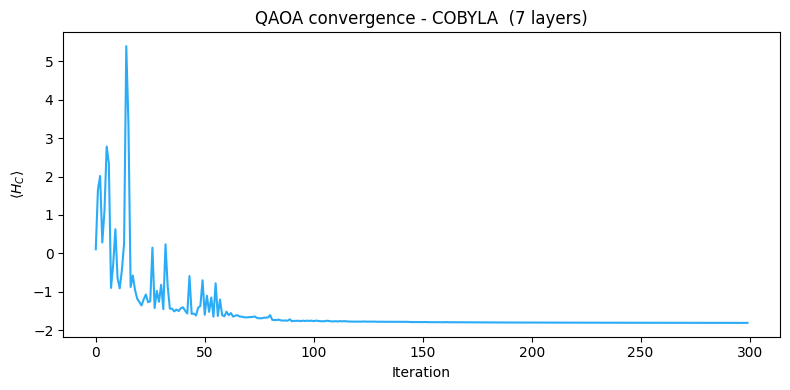

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(energies, color="#2aacf7")
plt.xlabel("Iteration")
plt.ylabel(r"$\langle H_C \rangle$")
plt.title(f"QAOA convergence - COBYLA  ({p} layers)")
plt.tight_layout()
plt.show()

With the optimized parameters in hand, we run the circuit one final time and collect the
full output probability distribution over all $2^n = 1024$ bitstrings. The 46 perfect
partitions (those with $|\text{diff}| = 0$) are highlighted in red. The table shows the
10 most probable bitstrings along with the two subset sums, and the total probability
mass on perfect partitions gives a single summary number for how well QAOA concentrated
amplitude on the optimal solutions.

   Bitstring     P(x)   sum P₁   sum P₂  |diff|
──────────────────────────────────────────────────
  0101001000   0.0033       27       27       0
  1010110111   0.0033       27       27       0
  0101001001   0.0032       25       29       4
  1010110110   0.0032       29       25       4
  0010110111   0.0032       29       25       4
  1101001000   0.0032       25       29       4
  0011100111   0.0031       28       26       2
  1100011000   0.0031       26       28       2
  0100011001   0.0031       26       28       2
  1011100110   0.0031       28       26       2

Total probability on perfect partitions: 0.1317


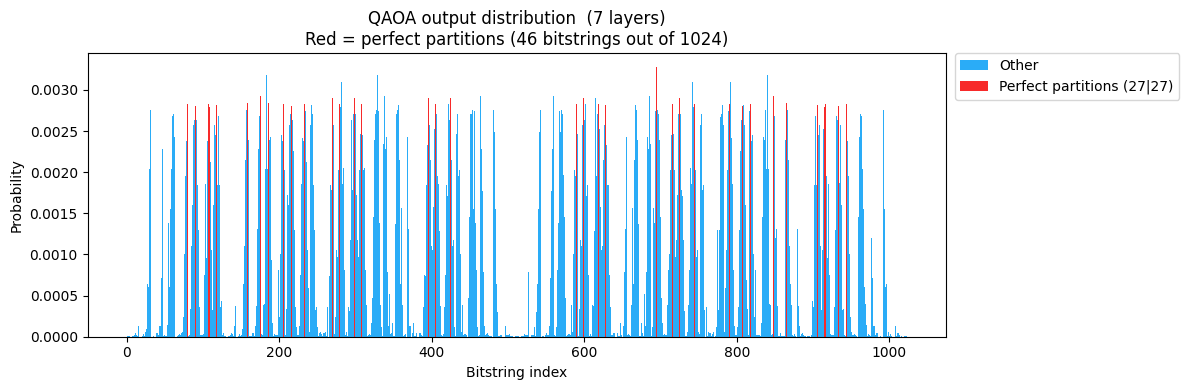

In [12]:
@qml.qnode(dev)
def probability_circuit(gamma, beta):
    for w in wires:
        qml.Hadamard(wires=w)
    qml.layer(qaoa_layer, p, gamma, beta)
    return qml.probs(wires=list(wires))

probs = probability_circuit(optimal_gamma, optimal_beta)

# Identify all perfect partitions using the same criterion as the table
optimal_idx = []
for idx in range(2**n):
    bits = format(idx, f"0{n}b")
    s1   = sum(C[i] for i in range(n) if bits[i] == '0')
    s2   = sum(C[i] for i in range(n) if bits[i] == '1')
    if s1 == s2:
        optimal_idx.append(idx)

# Print top-10 most probable bitstrings
top10 = np.argsort(probs)[::-1][:10]
print(f"{'Bitstring':>12}  {'P(x)':>7}  {'sum P₁':>7}  {'sum P₂':>7}  {'|diff|':>6}")
print("─" * 50)
for idx in top10:
    bits   = format(int(idx), f"0{n}b")
    s1     = sum(C[i] for i in range(n) if bits[i] == '0')
    s2     = sum(C[i] for i in range(n) if bits[i] == '1')
    print(f"{bits:>12}  {float(probs[idx]):>7.4f}  {s1:>7}  {s2:>7}  {abs(s1-s2):>6}")

print(f"\nTotal probability on perfect partitions: "
      f"{sum(float(probs[i]) for i in optimal_idx):.4f}")

# Bar chart with optimal solutions highlighted
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(2**n), probs, color="#2aacf7", width=1.0, label="Other")
ax.bar(optimal_idx, [probs[i] for i in optimal_idx],
       color="#f72a2a", width=1.0, label="Perfect partitions (27|27)")
ax.set_xlabel("Bitstring index")
ax.set_ylabel("Probability")
ax.set_title(f"QAOA output distribution  ({p} layers)\n"
             f"Red = perfect partitions ({len(optimal_idx)} bitstrings out of {2**n})")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

The output distribution can be further summarized by grouping all 1024 bitstrings by
their $|\text{diff}|$ value and computing the total probability mass in each group.
A uniform distribution would assign equal mass to every bitstring, so the uniform
baseline for a group of $k$ bitstrings is simply $\frac{k}{2^n}$. Comparing the QAOA mass
to this baseline shows whether the algorithm is enriching or suppressing each tier.

In [13]:
# Compute |diff| for every bitstring
diffs = np.array([
    abs(sum(C[i] for i in range(n) if format(idx, f"0{n}b")[i] == '0') -
        sum(C[i] for i in range(n) if format(idx, f"0{n}b")[i] == '1'))
    for idx in range(2**n)
])

# Group bitstring indices by their |diff| value
unique_diffs = sorted(set(diffs))
diff_to_idx  = {d: np.where(diffs == d)[0] for d in unique_diffs}

# ── Table: probability mass per tier vs uniform baseline ─────────────────────
print(f"{'|diff|':>8}  {'states in tier':>12}  {'QAOA prob (%)':>14}  {'uniform (%)':>12}")
print("─" * 55)
for d in unique_diffs[:12]:
    idx_group  = diff_to_idx[d]
    qaoa_mass  = float(np.sum(probs[idx_group]))
    unif_mass  = len(idx_group) / 2**n
    print(f"{d:>8}  {len(idx_group):>12}  {100*qaoa_mass:>14.2f}  {100*unif_mass:>12.2f}")

  |diff|  states in tier   QAOA prob (%)   uniform (%)
───────────────────────────────────────────────────────
       0            46           13.17          4.49
       2            72           19.89          7.03
       4            86           21.96          8.40
       6            76           15.99          7.42
       8            70           11.69          6.84
      10            82            9.51          8.01
      12            56            3.77          5.47
      14            76            2.62          7.42
      16            56            0.62          5.47
      18            54            0.11          5.27
      20            60            0.06          5.86
      22            34            0.09          3.32


QAOA is a heuristic: it does not guarantee finding the exact optimal solution, but it
can concentrate probability on good solutions. What counts as a good solution depends
on the problem and the application. Here we define near-optimal as any partition with
$|\text{diff}| \leq 4$, meaning the two subset sums differ by at most 4. A well-tuned
QAOA circuit should assign more probability to these near-optimal partitions than a
uniform random guess would, while suppressing probability on poor partitions with large
$|\text{diff}|$. 

In [14]:
# Near-optimal summary for chosen threshold 
threshold = 4   # |diff| <= this is "near-optimal"

near_idx   = np.where(diffs <= threshold)[0]
mass_near  = float(np.sum(probs[near_idx]))
mass_opt   = float(np.sum(probs[np.where(diffs == 0)[0]]))
unif_near  = len(near_idx) / 2**n

print(f"Near-optimal threshold : |diff| <= {threshold}")
print(f"  Partitions in range            : {len(near_idx)} / {2**n}  "
      f"({100*unif_near:.1f}%)")
print(f"  QAOA prob, perfect (|diff|=0)  : {100*mass_opt:.2f}%")
print(f"  QAOA prob, near-optimal        : {100*mass_near:.2f}%")
print(f"  Uniform baseline               : {100*unif_near:.2f}%")
print(f"  Probability ratio (QAOA / uniform) : {mass_near/unif_near:.2f}x")


Near-optimal threshold : |diff| <= 4
  Partitions in range            : 204 / 1024  (19.9%)
  QAOA prob, perfect (|diff|=0)  : 13.17%
  QAOA prob, near-optimal        : 55.03%
  Uniform baseline               : 19.92%
  Probability ratio (QAOA / uniform) : 2.76x


The two plots below visualize the same near-optimal analysis. The grouped bar chart
shows the total probability mass assigned to each $|\text{diff}|$ tier by QAOA and by
a uniform distribution. For a well-performing circuit, the QAOA bars should exceed the
uniform bars at small $|\text{diff}|$ values, reflecting enrichment near the optimal
solutions, and fall below the uniform bars at large $|\text{diff}|$ values, reflecting
suppression of poor partitions.

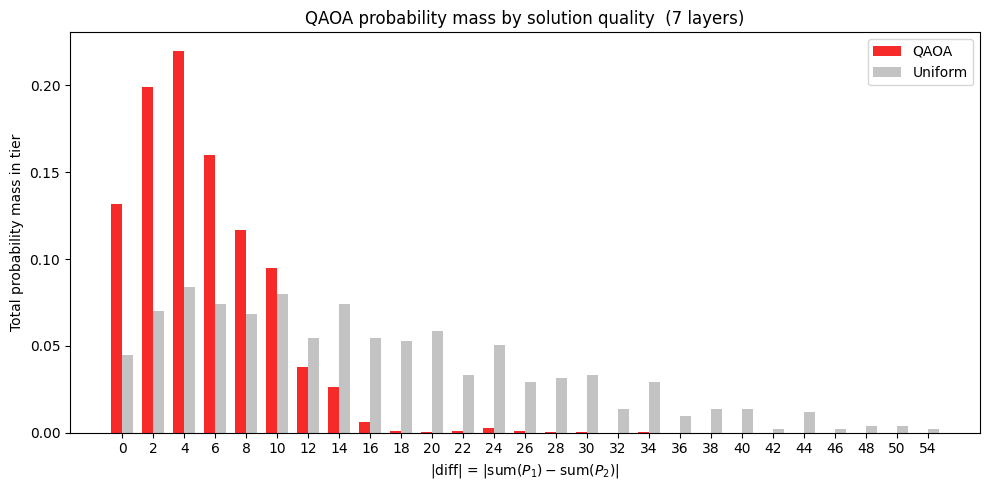

In [15]:
# Grouped bar chart: QAOA mass vs uniform per tier 
tiers       = unique_diffs
qaoa_masses = [float(np.sum(probs[diff_to_idx[d]])) for d in tiers]
unif_masses = [len(diff_to_idx[d]) / 2**n                for d in tiers]

x     = np.arange(len(tiers))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, qaoa_masses, width, color="#f72a2a", label="QAOA")
ax.bar(x + width/2, unif_masses, width, color="#aaaaaa", alpha=0.7, label="Uniform")
ax.set_xticks(x)
ax.set_xticklabels([str(int(d)) for d in tiers])
ax.set_xlabel(r"$|\mathrm{diff}|$ = $|\mathrm{sum}(P_1) - \mathrm{sum}(P_2)|$")
ax.set_ylabel("Total probability mass in tier")
ax.set_title(f"QAOA probability mass by solution quality  ({p} layers)")
ax.legend()
plt.tight_layout()
plt.show()

The cumulative probability plot shows how quickly total probability mass accumulates as
the $|\text{diff}|$ threshold is increased. A QAOA circuit that is concentrating
amplitude on good solutions should reach any given cumulative probability level at a
smaller threshold than the uniform baseline, meaning its curve lies above and to the
left of the uniform curve. The vertical line marks the near-optimal threshold of
$|\text{diff}| \leq 4$ chosen earlier.

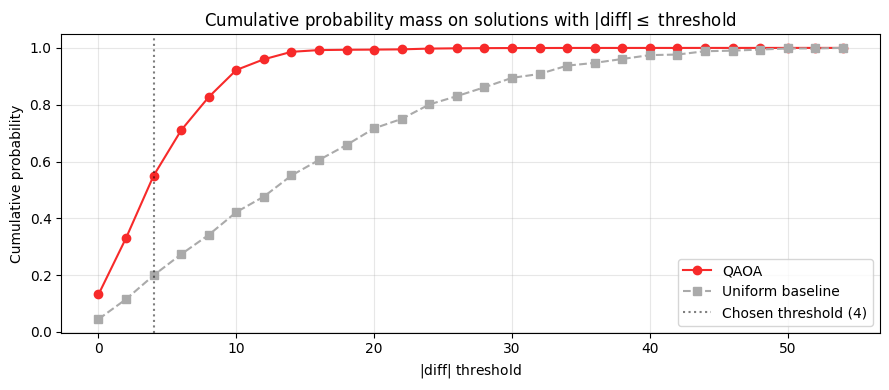

In [16]:
# Cumulative probability vs threshold 
thresh_vals  = range(0, int(max(diffs)) + 1, 2)
cumul_qaoa   = [float(np.sum(probs[np.where(diffs <= t)[0]])) for t in thresh_vals]
cumul_unif   = [float(np.sum(diffs <= t)) / 2**n               for t in thresh_vals]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresh_vals, cumul_qaoa, color="#f72a2a", marker='o', label="QAOA")
ax.plot(thresh_vals, cumul_unif, color="#aaaaaa", linestyle='--', marker='s',
        label="Uniform baseline")
ax.axvline(threshold, color='black', linestyle=':', alpha=0.5,
           label=f"Chosen threshold ({threshold})")
ax.set_xlabel(r"$|\mathrm{diff}|$ threshold")
ax.set_ylabel("Cumulative probability")
ax.set_title(r"Cumulative probability mass on solutions with $|\mathrm{diff}| \leq$ threshold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusion 

The Quantum Approximate Optimization Algorithm (QAOA) is a gate-based approach for
solving combinatorial optimization problems on quantum computers. It frames the problem
as a variational quantum circuit: by alternating between a cost unitary, which encodes
the objective function as phases on computational basis states, and a mixer unitary,
which redistributes amplitude across the solution space, the circuit builds up
constructive interference on good solutions over $p$ layers. The variational parameters
$(\gamma_k, \beta_k)$ are tuned by an outer optimization loop that uses the quantum
circuit to evaluate the objective. QAOA can be motivated as a discretized, gate-based counterpart of adiabatic quantum evolution. 
In the limit $p \to \infty$, with angles chosen to follow an annealing schedule, the QAOA circuit approaches a digitized version of the corresponding closed-system adiabatic evolution. Despite this
conceptual connection, the two approaches are not identical in practice: depending on
the problem structure, one may be better suited than the other in terms of resource
requirements or solution quality.

The number partitioning example in this tutorial illustrates both the strengths and the
honest limitations of QAOA at modest circuit depth. With $p = 7$ layers, the optimized
circuit concentrates roughly three times more probability on near-optimal partitions
than a random guess. At the same time, the perfect partitions do not dominate the output distribution, which is
consistent with QAOA being a heuristic: it improves the odds of sampling a good
solution, but does not guarantee finding the optimum.

Further results have deepened the connection between QAOA and quantum annealing.
[Sack and Serbyn](https://arxiv.org/abs/2101.05742) show that randomly
initialized QAOA parameters tend to converge to suboptimal local minima, and propose
initializing from a Trotterized quantum annealing schedule instead. This initialization
avoids false minima for a broad range of Trotter step sizes, and in numerical experiments
on MaxCut achieves performance comparable to the best result found over $2^p$ random
initializations, exponential in circuit depth, using a single optimization run.

Whether QAOA achieves a practical quantum advantage over classical heuristics such as
simulated annealing remains an open question. What it does offer is a natural framework
for running optimization on gate-based hardware, compatible with the broader ecosystem
of variational quantum algorithms.

---
### Appendix
---
### Appendix 1: Biography

- Edward Henry Farhi was born on June 26, 1952, in New York, United States. He attended the Bronx High School of Science, then Brandeis University, where he earned a B.A. and M.A. in physics. He received his Ph.D. in physics from Harvard University in 1978, with Howard Georgi as doctoral advisor; his dissertation is listed in Harvard’s thesis records as *Calculations in Quark Models* ([Harvard Physics PhD list](https://www.physics.harvard.edu/academics/phds1971-2000)). After postdoctoral work at Stanford Linear Accelerator Center (SLAC) and CERN, he joined the MIT faculty in 1982 and was Cecil and Ida Green Professor of Physics until 2018; he directed the MIT Center for Theoretical Physics from 2004 to 2016 ([MIT Physics faculty page](https://physics.mit.edu/faculty/edward-farhi/)). His work spans particle physics, astrophysics, general relativity, and quantum algorithms. Farhi, Goldstone, Gutmann and Sipser introduced [adiabatic quantum computation](https://arxiv.org/abs/quant-ph/0001106) and, in 2014, the Quantum Approximate Optimization Algorithm (QAOA) with Goldstone, Gutmann. Honours include a Sloan Research Fellowship (1984) and election as Fellow of the American Physical Society (2011) "for his seminal discoveries of new quantum algorithms and quantum computational paradigms" ([MIT Physics](https://physics.mit.edu/faculty/edward-farhi/)). Since 2018 he has been a full-time researcher at Google working on quantum computing while remaining connected to MIT ([MIT Physics](https://physics.mit.edu/faculty/edward-farhi/)).

- Jeffrey Goldstone was born in 1933, in Manchester, United Kingdom. He was educated at Manchester Grammar School and Trinity College, Cambridge (B.A. 1954, Ph.D. 1958), where his doctoral work on nuclear matter was supervised by Hans Bethe ([MIT Physics faculty page](https://physics.mit.edu/faculty/jeffrey-goldstone/)). He is known for the linked-cluster theorem in many-body theory and for the analysis of spontaneously broken symmetries and Nambu-Goldstone bosons. He was on the Cambridge faculty from 1962 to 1976, then moved to MIT in 1977 as Professor of Physics. He was Director of the MIT Center for Theoretical Physics from 1983 to 1989 and Cecil and Ida Green Professor of Physics from 1983 ([Wikipedia](https://en.wikipedia.org/wiki/Jeffrey_Goldstone); [MIT Physics](https://physics.mit.edu/faculty/jeffrey-goldstone/)). He has worked on quantum computation including co-authorship of the QAOA paper. He was elected Fellow of the Royal Society (1977), Fellow of the American Academy of Arts and Sciences (1977), and Fellow of the American Physical Society (1987), and received the Institute of Physics Guthrie Medal (1983), and the ICTP Dirac Medal (1991) ([MIT Physics](https://physics.mit.edu/faculty/jeffrey-goldstone/); [Royal Society](https://royalsociety.org/people/jeffrey-goldstone-11508/)).

---
### Appendix 2: References and Suggested Readings

1. Farhi, Edward; Goldstone, Jeffrey; and Gutmann, Sam (2014). *A Quantum Approximate Optimization Algorithm*. [[arXiv]](https://arxiv.org/abs/1411.4028).

2. Farhi, Edward; Goldstone, Jeffrey; Gutmann, Sam; and Sipser, Michael (2000). *Quantum Computation by Adiabatic Evolution*. [[arXiv]](https://arxiv.org/abs/quant-ph/0001106).

3. Hadfield, Stuart; Wang, Zhihui; O'Gorman, Bryan; Rieffel, Eleanor G.; Venturelli, Davide; and Biswas, Rupak (2019). *From the Quantum Approximate Optimization Algorithm to a Quantum Alternating Operator Ansatz*. Algorithms, 12(2), 34. Available at: https://doi.org/10.3390/a12020034 [[arXiv]](https://arxiv.org/abs/1709.03489).

4. Sack, Stefan H. and Serbyn, Maksym (2021). *Quantum Annealing Initialization of the Quantum Approximate Optimization Algorithm*. Quantum, 5, 491. Available at: https://doi.org/10.22331/q-2021-07-01-491 [[arXiv]](https://arxiv.org/abs/2101.05742).

5. Díez-Valle, Pablo; Gómez-Ruiz, Fernando J.; Porras, Diego; and García-Ripoll, Juan José (2026). *Universal Resources for QAOA and Quantum Annealing*. Physical Review Research, 8, 013211. Available at: https://doi.org/10.1103/hxv2-sbr7 [[arXiv]](https://arxiv.org/abs/2506.03241).

6. Hen, Itay and Sarandy, Marcelo S. (2016). *Driver Hamiltonians for Constrained Optimization in Quantum Annealing*. Physical Review A, 93, 062312. Available at: https://doi.org/10.1103/PhysRevA.93.062312 [[arXiv]](https://arxiv.org/abs/1602.07942).

7. He, Zichang; Shaydulin, Ruslan; Chakrabarti, Shouvanik; Herman, Dylan; Li, Changhao; Sun, Yue; and Pistoia, Marco (2023). *Alignment between Initial State and Mixer Improves QAOA Performance for Constrained Optimization*. npj Quantum Information, 9, 121. Available at: https://doi.org/10.1038/s41534-023-00787-5 [[arXiv]](https://arxiv.org/abs/2305.03857).

8. Farhi, Edward and Harrow, Aram W. (2016). *Quantum Supremacy through the Quantum Approximate Optimization Algorithm*. [[arXiv]](https://arxiv.org/abs/1602.07674).

9. Blekos, Kostas; Brand, Dean; Ceschini, Andrea; Chou, Chiao-Hui; Li, Rui-Hao; Pandya, Komal; and Summer, Alessandro (2024). *A Review on Quantum Approximate Optimization Algorithm and its Variants*. Physics Reports, 1068, 1-66. Available at: https://doi.org/10.1016/j.physrep.2024.03.002 [[arXiv]](https://arxiv.org/abs/2306.09198).

10. Ceroni, Jack (2020). *Intro to QAOA*. PennyLane Demos. Last updated September 22, 2025. Available at: [https://pennylane.ai/qml/demos/tutorial_qaoa_intro](https://pennylane.ai/qml/demos/tutorial_qaoa_intro).

11. IBM Quantum (n.d.). *Quantum Approximate Optimization Algorithm*. IBM Quantum Learning. Accessed April, 2026. Available at: [https://quantum.cloud.ibm.com/docs/en/tutorials/quantum-approximate-optimization-algorithm](https://quantum.cloud.ibm.com/docs/en/tutorials/quantum-approximate-optimization-algorithm).

12. Entropica Labs (n.d.). *OpenQAOA: An Advanced Multi-Backend SDK for Quantum Optimization*. Available at: [https://openqaoa.entropicalabs.com](https://openqaoa.entropicalabs.com).

13. Peskin, Michael E. and Schroeder, Daniel V. (1995). *An Introduction to Quantum Field Theory*. Westview Press.

14. MIT OpenCourseWare (2017). *Quantum Theory I, Lecture 8: Time Evolution*. Course 8.321. Available at: [https://ocw.mit.edu/courses/8-321-quantum-theory-i-fall-2017/579cb61c4eaa494b9adb90830d921099_MIT8_321F17_lec8.pdf](https://ocw.mit.edu/courses/8-321-quantum-theory-i-fall-2017/579cb61c4eaa494b9adb90830d921099_MIT8_321F17_lec8.pdf).

15. Physics Stack Exchange (2015). *Does the Time-Ordering Operator Have a Rigorous Definition?* Available at: [https://physics.stackexchange.com/questions/179429](https://physics.stackexchange.com/questions/179429/does-the-time-ordering-operator-have-a-rigorous-definition).